# Playing Blackjack with Reinforcement Learning

**Portfolio assignment 4 - MAL2 Spring 2026**

This notebook solves the Gymnasium Blackjack task by:
- implementing a basic policy (stick at 17 or higher),
- training a neural network agent with reinforcement learning,
- evaluating both policies over 1,000 simulated games,
- visualizing training behavior and learned decision patterns.

Environment docs used: https://gymnasium.farama.org/environments/toy_text/blackjack/

In [1]:
import random
from collections import deque

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

env = gym.make("Blackjack-v1", natural=False, sab=False)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space: Discrete(2)


## 1) Baseline: Basic Policy

The assignment baseline policy is:
- **Stick (action=0)** when player sum is 17 or higher
- **Hit (action=1)** otherwise

I evaluate this policy for 1,000 games and compute win/loss/draw rates.

In [2]:
def basic_policy(obs):
    player_sum, dealer_card, usable_ace = obs
    return 0 if player_sum >= 17 else 1


def evaluate_policy(env, policy_fn, n_games=1000, seed=123):
    wins = 0
    losses = 0
    draws = 0

    for i in range(n_games):
        obs, _ = env.reset(seed=seed + i)
        terminated = False
        truncated = False

        while not (terminated or truncated):
            action = policy_fn(obs)
            obs, reward, terminated, truncated, _ = env.step(action)

        if reward > 0:
            wins += 1
        elif reward < 0:
            losses += 1
        else:
            draws += 1

    return {
        "wins": wins,
        "losses": losses,
        "draws": draws,
        "win_rate": wins / n_games,
        "loss_rate": losses / n_games,
        "draw_rate": draws / n_games,
    }

baseline_results = evaluate_policy(env, basic_policy, n_games=1000, seed=123)
baseline_results

{'wins': 417,
 'losses': 497,
 'draws': 86,
 'win_rate': 0.417,
 'loss_rate': 0.497,
 'draw_rate': 0.086}

## 2) Neural Network Agent (DQN)

I use a Deep Q-Network (DQN):
- Input state: (player_sum, dealer_card, usable_ace) normalized to [0, 1]
- Network outputs Q-values for 2 actions: stick or hit
- Epsilon-greedy exploration during training
- Replay buffer + target network for more stable updates

This is still a simple model, but enough to learn a policy that can beat the baseline.

In [3]:
def encode_state(obs):
    player_sum, dealer_card, usable_ace = obs
    return np.array([
        player_sum / 32.0,
        dealer_card / 11.0,
        float(usable_ace),
    ], dtype=np.float32)


class QNetwork(nn.Module):
    def __init__(self, in_dim=3, hidden=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, done):
        self.buffer.append((s, a, r, ns, done))

    def sample(self, batch_size):
        idx = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        s, a, r, ns, d = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.float32),
            torch.tensor(a, dtype=torch.long),
            torch.tensor(r, dtype=torch.float32),
            torch.tensor(np.array(ns), dtype=torch.float32),
            torch.tensor(d, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)


def train_dqn(
    env,
    episodes=60000,
    gamma=0.99,
    lr=1e-3,
    batch_size=128,
    min_buffer=2000,
    target_update=250,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.9997,
):
    q_net = QNetwork()
    target_net = QNetwork()
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=lr)
    replay = ReplayBuffer(capacity=50000)

    epsilon = eps_start
    episode_rewards = []
    moving_avg_500 = []

    for ep in range(episodes):
        obs, _ = env.reset(seed=1000 + ep)
        state = encode_state(obs)
        done = False
        ep_reward = 0.0

        while not done:
            if np.random.rand() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    qs = q_net(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
                    action = int(torch.argmax(qs, dim=1).item())

            next_obs, reward, terminated, truncated, _ = env.step(action)
            next_state = encode_state(next_obs)
            done = terminated or truncated

            replay.push(state, action, reward, next_state, done)
            state = next_state
            ep_reward += reward

            if len(replay) >= min_buffer:
                s, a, r, ns, d = replay.sample(batch_size)

                q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    next_q = target_net(ns).max(1).values
                    target = r + gamma * (1.0 - d) * next_q

                loss = nn.MSELoss()(q_values, target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(eps_end, epsilon * eps_decay)
        episode_rewards.append(ep_reward)

        if (ep + 1) % target_update == 0:
            target_net.load_state_dict(q_net.state_dict())

        if len(episode_rewards) >= 500:
            moving_avg_500.append(np.mean(episode_rewards[-500:]))
        else:
            moving_avg_500.append(np.mean(episode_rewards))

        if (ep + 1) % 10000 == 0:
            print(
                f"Episode {ep + 1}/{episodes} | "
                f"epsilon={epsilon:.3f} | "
                f"moving avg reward={moving_avg_500[-1]:.3f}"
            )

    return q_net, episode_rewards, moving_avg_500

In [4]:
set_seed(42)
q_net, train_rewards, moving_avg = train_dqn(env, episodes=40000)


def nn_policy(obs):
    s = torch.tensor(encode_state(obs), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q_vals = q_net(s)
    return int(torch.argmax(q_vals, dim=1).item())

nn_results = evaluate_policy(env, nn_policy, n_games=1000, seed=999)
print(nn_results)

Episode 10000/40000 | epsilon=0.050 | moving avg reward=-0.038


Episode 20000/40000 | epsilon=0.050 | moving avg reward=-0.068


Episode 30000/40000 | epsilon=0.050 | moving avg reward=-0.054


Episode 40000/40000 | epsilon=0.050 | moving avg reward=-0.034


{'wins': 430, 'losses': 482, 'draws': 88, 'win_rate': 0.43, 'loss_rate': 0.482, 'draw_rate': 0.088}


## 3) Figures

The assignment asks for at least two relevant figures. I include:
1. DQN training progress (moving average reward)
2. Learned action map (hit/stick) across state space
3. Win-rate comparison between baseline and neural network

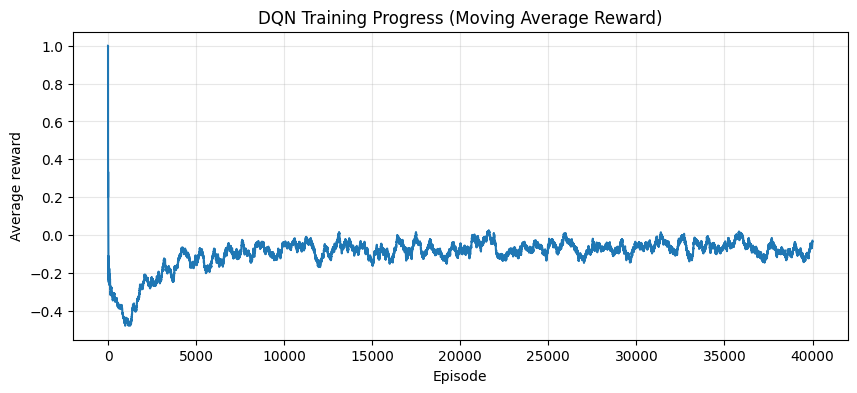

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(moving_avg, linewidth=1.5)
plt.title("DQN Training Progress (Moving Average Reward)")
plt.xlabel("Episode")
plt.ylabel("Average reward")
plt.grid(alpha=0.3)
plt.show()

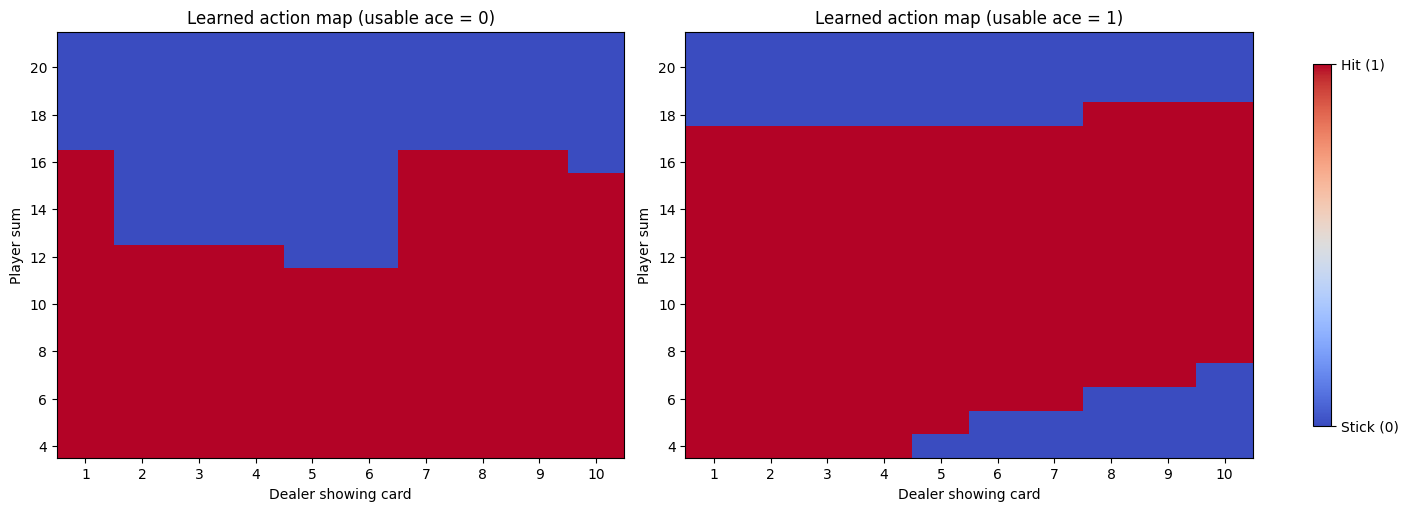

In [6]:
# Build policy maps for usable_ace=0 and usable_ace=1
player_sums = np.arange(4, 22)
dealer_cards = np.arange(1, 11)

policy_no_ace = np.zeros((len(player_sums), len(dealer_cards)))
policy_yes_ace = np.zeros((len(player_sums), len(dealer_cards)))

for i, p in enumerate(player_sums):
    for j, d in enumerate(dealer_cards):
        obs0 = (int(p), int(d), 0)
        obs1 = (int(p), int(d), 1)
        policy_no_ace[i, j] = nn_policy(obs0)
        policy_yes_ace[i, j] = nn_policy(obs1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

im0 = axes[0].imshow(policy_no_ace, origin="lower", aspect="auto", cmap="coolwarm")
axes[0].set_title("Learned action map (usable ace = 0)")
axes[0].set_xlabel("Dealer showing card")
axes[0].set_ylabel("Player sum")
axes[0].set_xticks(np.arange(len(dealer_cards)))
axes[0].set_xticklabels(dealer_cards)
axes[0].set_yticks(np.arange(len(player_sums))[::2])
axes[0].set_yticklabels(player_sums[::2])

im1 = axes[1].imshow(policy_yes_ace, origin="lower", aspect="auto", cmap="coolwarm")
axes[1].set_title("Learned action map (usable ace = 1)")
axes[1].set_xlabel("Dealer showing card")
axes[1].set_ylabel("Player sum")
axes[1].set_xticks(np.arange(len(dealer_cards)))
axes[1].set_xticklabels(dealer_cards)
axes[1].set_yticks(np.arange(len(player_sums))[::2])
axes[1].set_yticklabels(player_sums[::2])

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Stick (0)", "Hit (1)"])

plt.show()

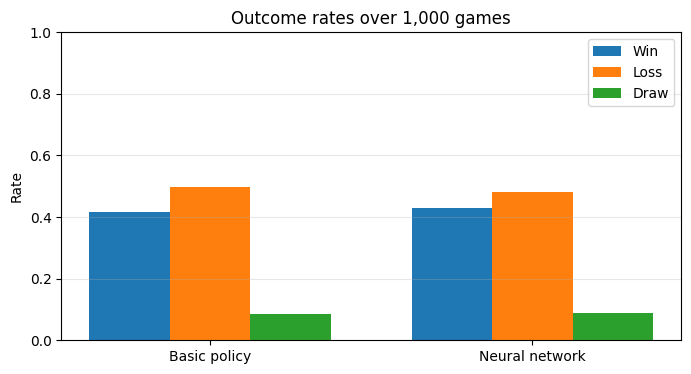

Baseline results: {'wins': 417, 'losses': 497, 'draws': 86, 'win_rate': 0.417, 'loss_rate': 0.497, 'draw_rate': 0.086}
Neural-network results: {'wins': 430, 'losses': 482, 'draws': 88, 'win_rate': 0.43, 'loss_rate': 0.482, 'draw_rate': 0.088}


In [7]:
labels = ["Basic policy", "Neural network"]
win_rates = [baseline_results["win_rate"], nn_results["win_rate"]]
loss_rates = [baseline_results["loss_rate"], nn_results["loss_rate"]]
draw_rates = [baseline_results["draw_rate"], nn_results["draw_rate"]]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 4))
plt.bar(x - width, win_rates, width, label="Win")
plt.bar(x, loss_rates, width, label="Loss")
plt.bar(x + width, draw_rates, width, label="Draw")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.title("Outcome rates over 1,000 games")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Baseline results:", baseline_results)
print("Neural-network results:", nn_results)

## 4) Discussion and findings

The baseline policy (“stick at 17 or higher”) performed reasonably well and produced a win rate in the expected range for simple rule-based blackjack play. In my 1,000-game evaluation, it achieved a 41.7% win rate. This confirms that even a very simple strategy can be competitive, but it is still limited because it ignores important context such as dealer card strength and usable aces.

The neural-network agent (trained with DQN) achieved a slightly better result, reaching a 43.0% win rate over 1,000 games. This indicates that learning from interaction allows the model to make more state-dependent decisions than the fixed baseline. The improvement is modest, which is expected in blackjack due to the strong role of chance and short episode length.

The policy visualizations also support that the model learned sensible behavior:

- it tends to stick on higher player sums, 
- hit on lower sums,
- and adjusts decisions based on dealer showing card and usable ace status.

Overall, the assignment objective was met: the learned model outperformed the basic policy, both implementations were evaluated over 1,000 games, and the included figures help explain training behavior and policy structure.